In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv")
sample_submission_df = pd.read_csv("/kaggle/input/playground-series-s5e11/sample_submission.csv")

In [3]:
# train_df.drop("grade_subgrade", axis = 1,inplace = True)
# test_df.drop("grade_subgrade", axis = 1,inplace = True)
# train_df.drop("gender", axis = 1,inplace = True)
# test_df.drop("gender", axis = 1,inplace = True)

In [4]:
train_df.shape

(593994, 13)

In [5]:
train_df.sample(10)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
120735,120735,24402.08,0.094,696,6487.93,12.67,Female,Single,Bachelor's,Employed,Education,C1,1.0
407068,407068,20863.22,0.082,728,5389.88,12.70,Female,Single,Bachelor's,Employed,Debt consolidation,C5,1.0
155147,155147,37579.55,0.239,692,13144.26,8.36,Male,Married,Other,Employed,Debt consolidation,C5,1.0
103452,103452,86655.60,0.095,616,25446.12,13.80,Male,Widowed,Master's,Employed,Debt consolidation,D5,0.0
351435,351435,59920.56,0.050,715,12309.68,13.69,Male,Single,Master's,Retired,Debt consolidation,C3,1.0
108479,108479,33783.81,0.071,703,11357.17,11.62,Male,Married,Bachelor's,Employed,Business,C3,1.0
309559,309559,17173.05,0.215,663,23645.79,17.14,Male,Married,Master's,Student,Debt consolidation,D4,0.0
24606,24606,47900.58,0.093,699,8441.22,12.48,Female,Married,Bachelor's,Employed,Debt consolidation,C5,1.0
259793,259793,121575.30,0.049,746,18708.63,10.11,Female,Married,High School,Employed,Car,B4,1.0
583299,583299,19169.64,0.037,654,25883.37,12.69,Female,Divorced,Bachelor's,Employed,Debt consolidation,D2,1.0


In [6]:
test_df.sample(10)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
243376,837370,74954.39,0.065,761,8166.59,11.53,Female,Single,Master's,Employed,Debt consolidation,B1
164048,758042,79324.76,0.174,739,8994.45,8.24,Female,Single,Bachelor's,Unemployed,Debt consolidation,C5
179808,773802,37197.62,0.039,641,17587.65,14.24,Female,Single,Other,Employed,Education,D4
122624,716618,71691.75,0.055,766,13349.25,12.52,Male,Divorced,High School,Employed,Debt consolidation,B1
227066,821060,35509.27,0.096,812,19841.61,10.45,Male,Single,High School,Self-employed,Other,A2
198421,792415,22807.53,0.090,721,22009.94,9.15,Female,Married,High School,Retired,Other,C5
103755,697749,56493.82,0.051,590,14094.73,13.97,Female,Single,Bachelor's,Employed,Debt consolidation,E5
91918,685912,28003.28,0.050,749,26983.39,9.11,Male,Single,Bachelor's,Employed,Car,B2
73561,667555,44991.58,0.089,723,11693.78,11.68,Male,Single,Master's,Employed,Debt consolidation,C4
151464,745458,51484.61,0.053,734,25404.07,14.30,Female,Single,Master's,Retired,Other,C4


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [8]:
train_df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [9]:
train_df.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [10]:
categorical_column = []
numerical_column = []
for i in train_df.columns:
    if train_df[i].dtype == "object":
        categorical_column.append(i)
    else:
        numerical_column.append(i)

In [11]:
for i in categorical_column:
    print(f"{i} ->    {train_df[i].unique()}")

gender ->    ['Female' 'Male' 'Other']
marital_status ->    ['Single' 'Married' 'Divorced' 'Widowed']
education_level ->    ['High School' "Master's" "Bachelor's" 'PhD' 'Other']
employment_status ->    ['Self-employed' 'Employed' 'Unemployed' 'Retired' 'Student']
loan_purpose ->    ['Other' 'Debt consolidation' 'Home' 'Education' 'Vacation' 'Car'
 'Medical' 'Business']
grade_subgrade ->    ['C3' 'D3' 'C5' 'F1' 'D1' 'D5' 'C2' 'C1' 'F5' 'D4' 'C4' 'D2' 'E5' 'B1'
 'B2' 'F4' 'A4' 'E1' 'F2' 'B4' 'E4' 'B3' 'E3' 'B5' 'E2' 'F3' 'A5' 'A3'
 'A1' 'A2']


In [12]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline

In [13]:
sns.set(rc={'figure.figsize':(14,8)})

<Axes: xlabel='loan_paid_back', ylabel='count'>

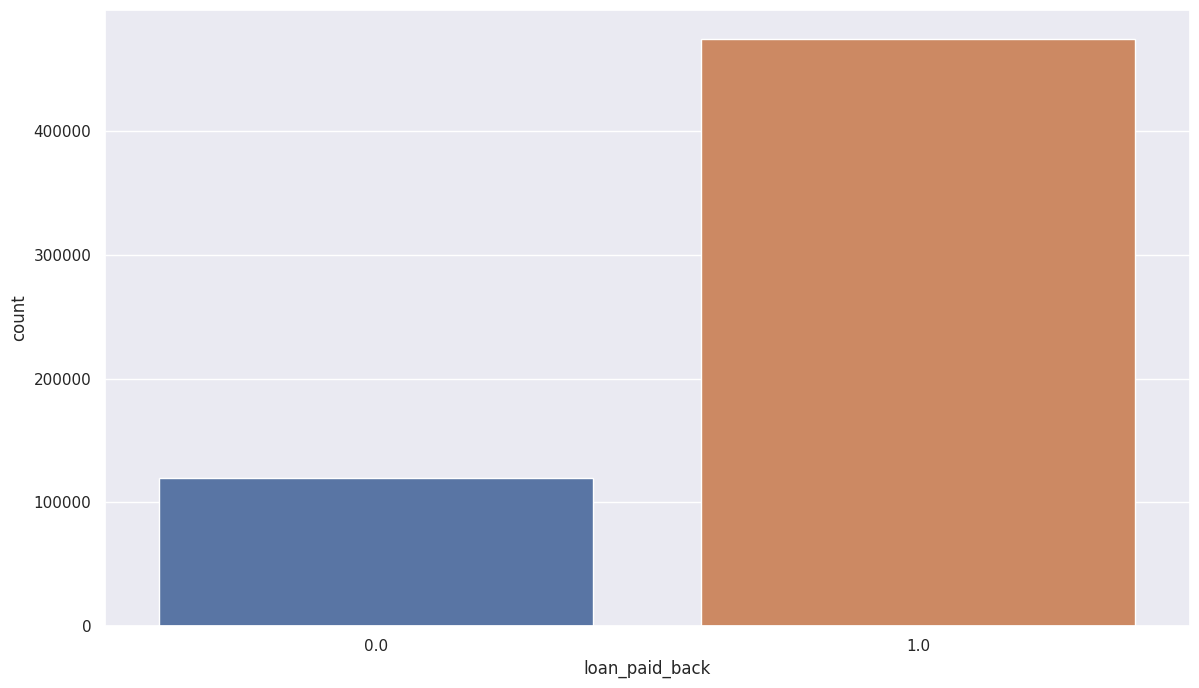

In [14]:
sns.countplot(data = train_df, x = "loan_paid_back")

<Axes: >

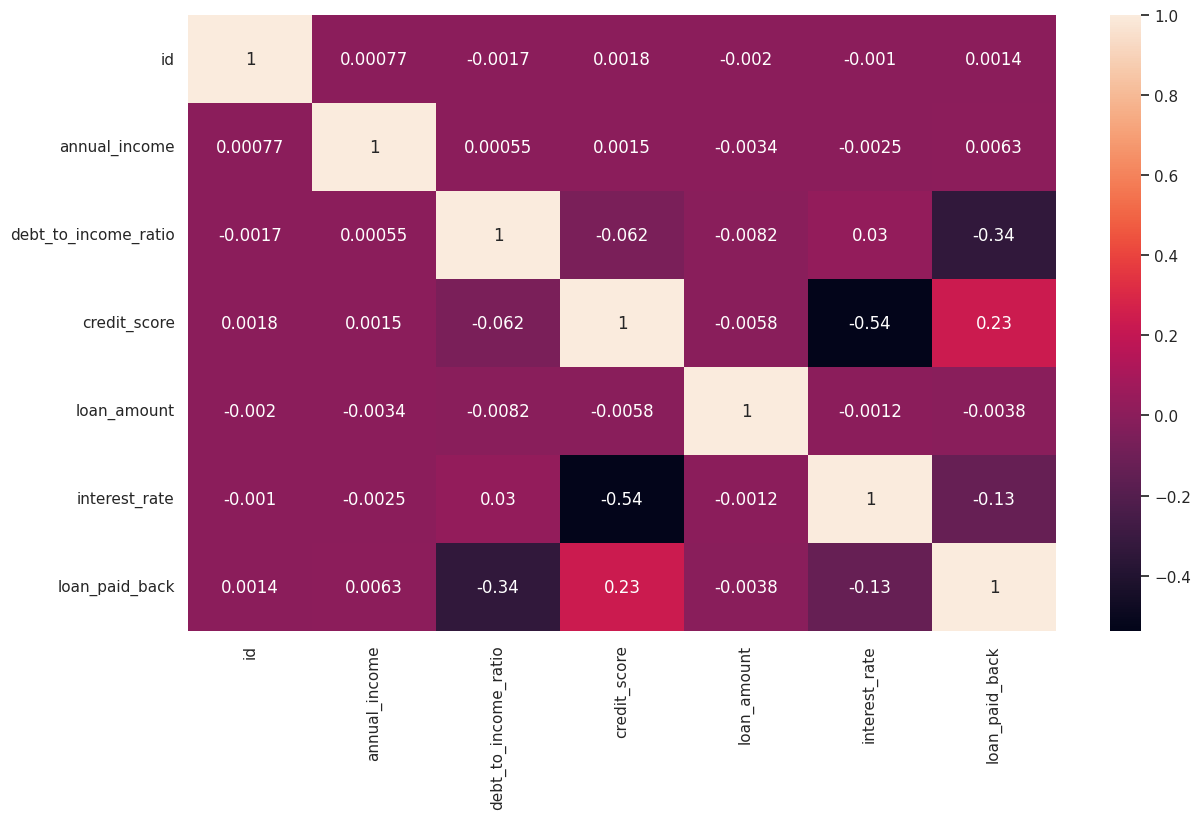

In [15]:
sns.heatmap(train_df[numerical_column].corr(),annot = True)

<Axes: xlabel='grade_subgrade', ylabel='count'>

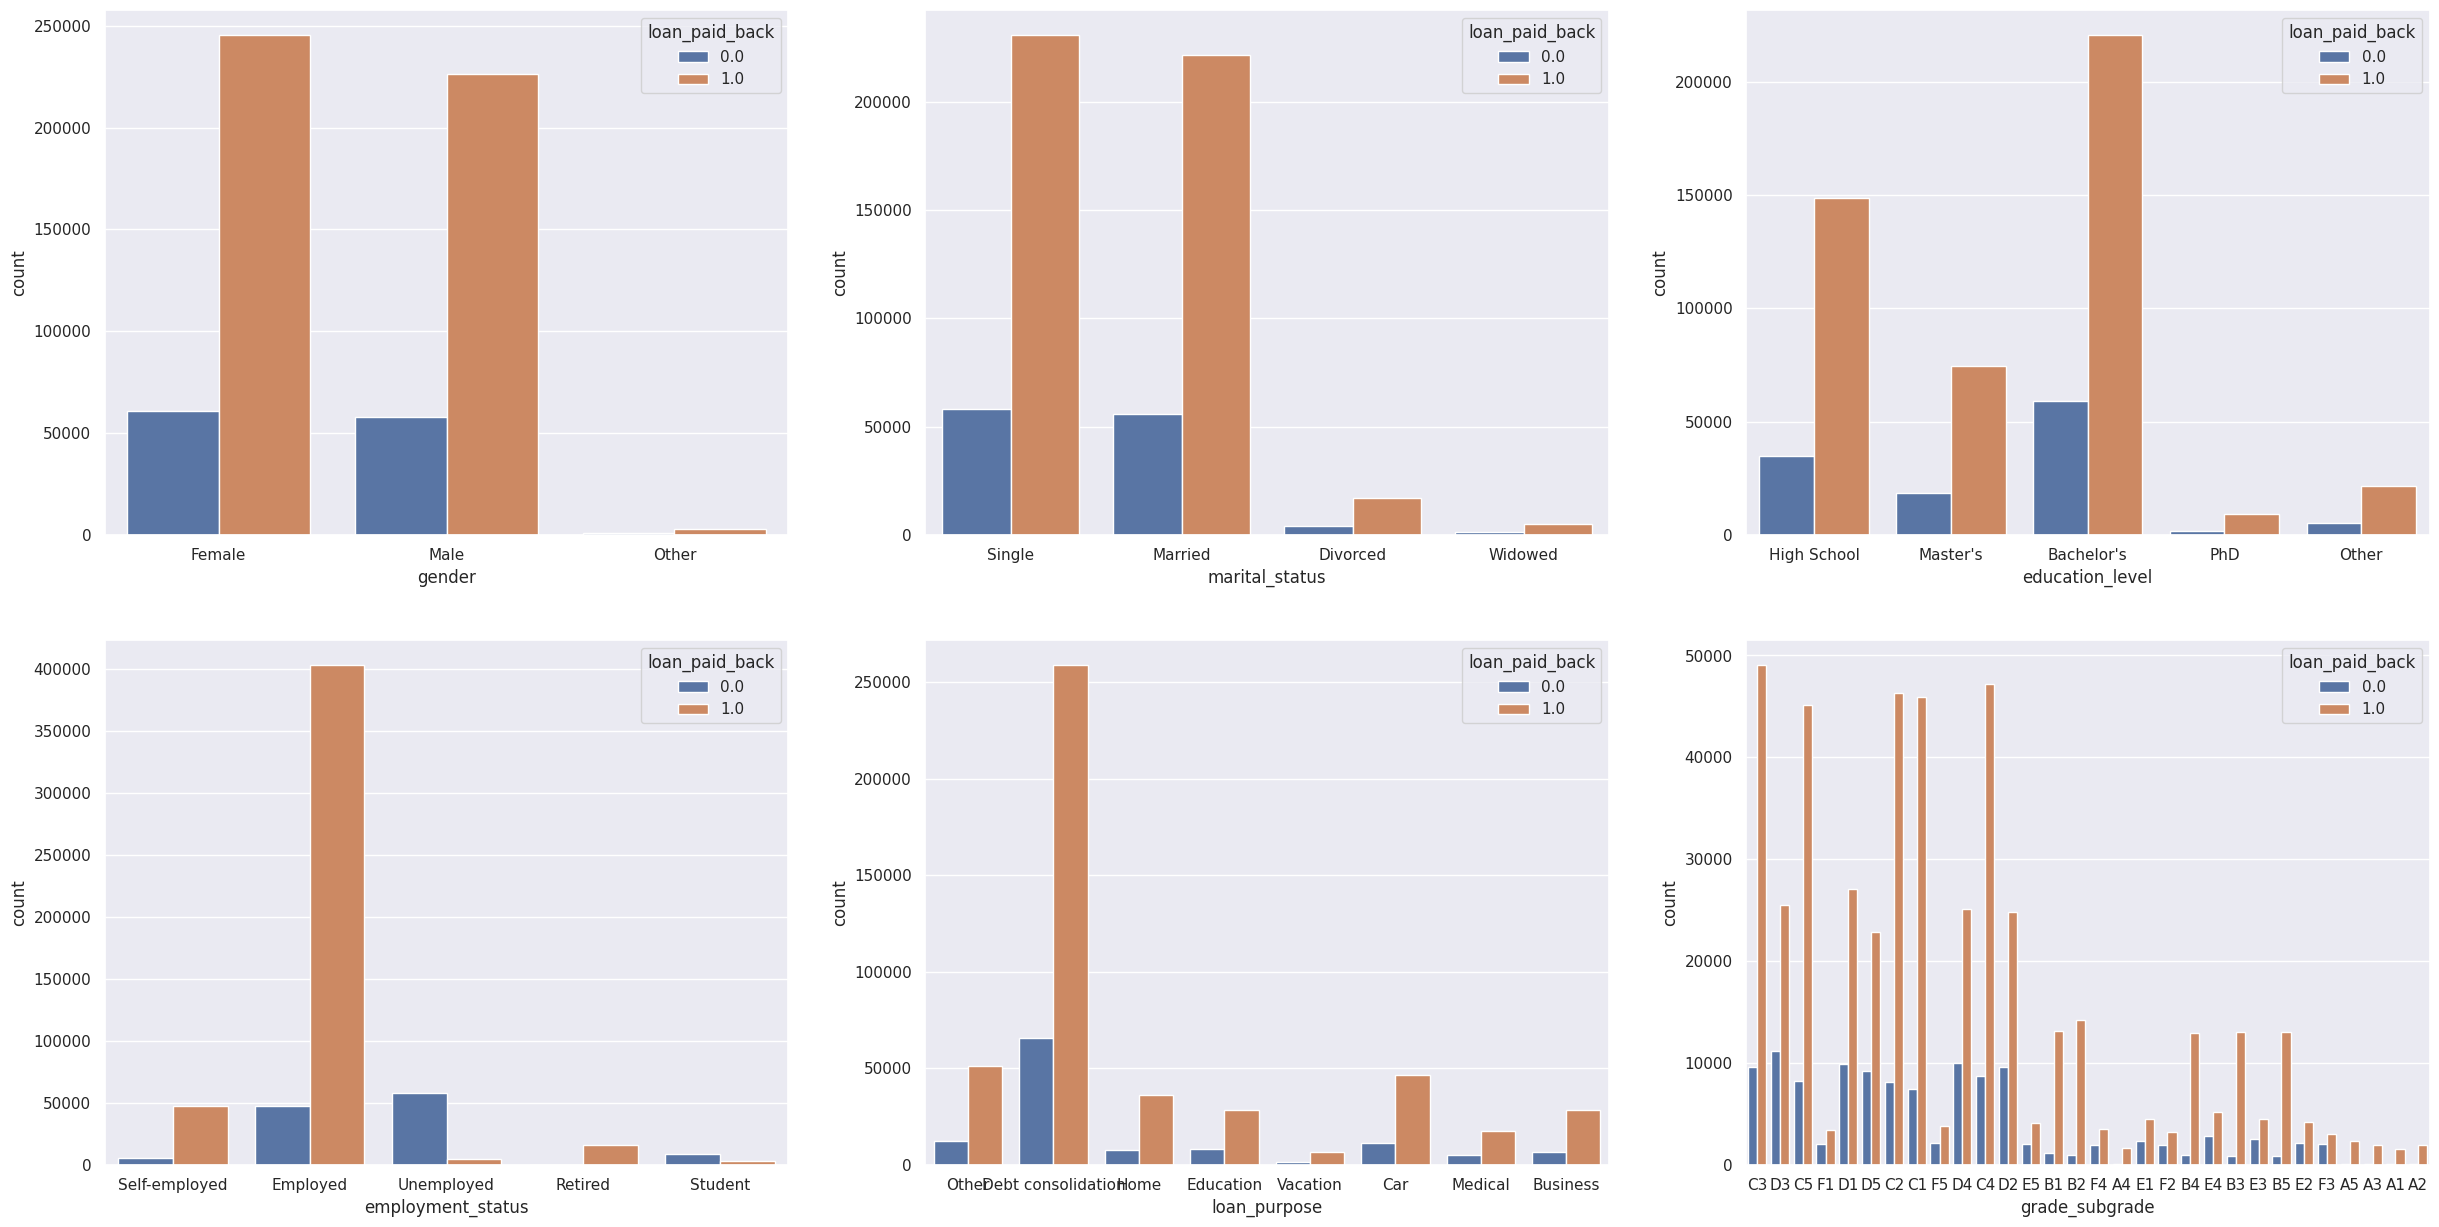

In [16]:
plt.figure(figsize = (30,15))

plt.subplot(2,3,1)
sns.countplot(data = train_df, x = "gender", hue = "loan_paid_back")

plt.subplot(2,3,2)
sns.countplot(data = train_df, x = "marital_status", hue = "loan_paid_back")

plt.subplot(2,3,3)
sns.countplot(data = train_df, x = "education_level", hue = "loan_paid_back")

plt.subplot(2,3,4)
sns.countplot(data = train_df, x = "employment_status", hue = "loan_paid_back")

plt.subplot(2,3,5)
sns.countplot(data = train_df, x = "loan_purpose", hue = "loan_paid_back")

plt.subplot(2,3,6)
sns.countplot(data = train_df, x = "grade_subgrade", hue = "loan_paid_back")

In [17]:
from sklearn.preprocessing import LabelEncoder
label_encoding = {}
for column in categorical_column:
    le = LabelEncoder()
    train_df[column] = le.fit_transform(train_df[column])
    test_df[column] = le.transform(test_df[column])
    label_encoding[column] = le

In [18]:
train_df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0
2,2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0
3,3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0
4,4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,0,2,1,0,0,12,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,1,2,0,0,2,29,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,0,1,0,0,2,10,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,1,2,0,0,2,6,1.0


In [19]:
test_df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,0,2,1,0,6,19
1,593995,46626.39,0.093,732,15492.25,12.85,0,1,2,0,6,10
2,593996,54954.89,0.367,611,3796.41,13.29,1,2,0,0,2,15
3,593997,25644.63,0.110,671,6574.30,9.57,0,2,0,0,2,12
4,593998,25169.64,0.081,688,17696.89,12.80,0,1,4,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,0,2,0,0,2,6
254565,848559,48846.47,0.091,634,20284.33,9.58,0,1,1,0,2,18
254566,848560,20668.52,0.096,718,26387.55,9.00,1,2,2,0,2,13
254567,848561,34105.09,0.094,739,11107.36,9.81,1,2,0,0,0,11


In [20]:
X = train_df.iloc[:,:-1]
y = train_df.iloc[:,-1]

In [21]:
!pip install catboost xgboost lightgbm -q

In [22]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = [
    ("catboost", CatBoostClassifier(verbose = 0, bootstrap_type =  'Bernoulli', iterations = 1401, depth = 2, learning_rate = 0.19571794886505098, l2_leaf_reg = 6.101681213391301, grow_policy = 'Depthwise', subsample = 0.9951229406746853)),
    ("lightgbm", LGBMClassifier(verbosity = -1, boosting_type = 'gbdt', learning_rate = 0.027463607417161504, num_leaves = 145, max_depth = 15, lambda_l1 = 3.8001258819701387, lambda_l2 = 3.153229343778846, feature_fraction = 0.6230583010360565, bagging_fraction = 0.9501461096019161, bagging_freq = 2, n_estimators = 709)),
    ("xgboost", XGBClassifier(n_estimators = 1547, max_depth = 8, learning_rate = 0.041837604673832025, subsample = 0.6621413262790034, colsample_bytree = 0.4155481155770492, gamma = 2.5487506361753907, min_child_weight = 5, reg_alpha = 2.1526565977480957e-07))
]

oof_preds = np.zeros((X.shape[0], len(models)))
test_preds = np.zeros((test_df.shape[0], len(models)))

# Generate OOF predictions
for i, (name, model) in enumerate(models):
    print(f"Training {name}...")

    fold = 0
    for train_idx, val_idx in kf.split(X):
        fold += 1

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        # Validation probabilites → OOF
        oof_preds[val_idx, i] = model.predict_proba(X_val)[:, 1]

        # Test predictions (store avg across folds)
        test_preds[:, i] += model.predict_proba(test_df)[:, 1] / kf.n_splits

        print(f"{name} - Fold {fold}: ROC-AUC = {roc_auc_score(y_val, oof_preds[val_idx, i]):.8f}")

Training catboost...
catboost - Fold 1: ROC-AUC = 0.92443492
catboost - Fold 2: ROC-AUC = 0.92391580
catboost - Fold 3: ROC-AUC = 0.92423815
catboost - Fold 4: ROC-AUC = 0.92157168
catboost - Fold 5: ROC-AUC = 0.92394952
Training lightgbm...
lightgbm - Fold 1: ROC-AUC = 0.92395503
lightgbm - Fold 2: ROC-AUC = 0.92332198
lightgbm - Fold 3: ROC-AUC = 0.92314930
lightgbm - Fold 4: ROC-AUC = 0.92076466
lightgbm - Fold 5: ROC-AUC = 0.92324611
Training xgboost...
xgboost - Fold 1: ROC-AUC = 0.92293411
xgboost - Fold 2: ROC-AUC = 0.92278464
xgboost - Fold 3: ROC-AUC = 0.92233892
xgboost - Fold 4: ROC-AUC = 0.91969905
xgboost - Fold 5: ROC-AUC = 0.92251858


In [24]:
oof_preds

array([[0.97950989, 0.98136916, 0.98115671],
       [0.49186867, 0.56645501, 0.52767134],
       [0.91783502, 0.9194952 , 0.9135325 ],
       ...,
       [0.97240499, 0.9680815 , 0.96609294],
       [0.99333326, 0.99452751, 0.9937737 ],
       [0.98443436, 0.98927606, 0.98680371]])

In [25]:
# Train meta model on OOF predictions
meta_model = LogisticRegression()
meta_model.fit(oof_preds, y)

# Final stacked test predictions
stacked_test_preds = meta_model.predict_proba(test_preds)[:, 1]

print("Stacking complete! 🎯")

Stacking complete! 🎯


In [26]:
df = pd.DataFrame(columns = ["id", "loan_paid_back"])
df["id"] = test_df["id"]
df["loan_paid_back"] = stacked_test_preds

df.to_csv("submission.csv",index = False)

In [27]:
df

,id,loan_paid_back
0,593994,0.945952
1,593995,0.958544
2,593996,0.543157
3,593997,0.941361
4,593998,0.952778
...,...,...
254564,848558,0.962021
254565,848559,0.874554
254566,848560,0.953013
254567,848561,0.959306


In [28]:
# xg = XGBClassifier(n_estimators = 1547, max_depth = 8, learning_rate = 0.041837604673832025, subsample = 0.6621413262790034, colsample_bytree = 0.4155481155770492, gamma = 2.5487506361753907, min_child_weight = 5, reg_alpha = 2.1526565977480957e-07)
# cb = CatBoostClassifier(verbose = 0, bootstrap_type =  'Bernoulli', iterations = 1401, depth = 2, learning_rate = 0.19571794886505098, l2_leaf_reg = 6.101681213391301, grow_policy = 'Depthwise', subsample = 0.9951229406746853)
# lgbm = LGBMClassifier(verbosity = -1, boosting_type = 'gbdt', learning_rate = 0.027463607417161504, num_leaves = 145, max_depth = 15, lambda_l1 = 3.8001258819701387, lambda_l2 = 3.153229343778846, feature_fraction = 0.6230583010360565, bagging_fraction = 0.9501461096019161, bagging_freq = 2, n_estimators = 709)

In [29]:
# xg.fit(X_train,y_train)
# cb.fit(X_train,y_train)
# lgbm.fit(X_train,y_train)

In [30]:
# X_test_xg_pred = xg.predict(X_test)
# X_test_cb_pred = cb.predict(X_test)
# X_test_lgbm_pred = lgbm.predict(X_test)

In [31]:
# from sklearn.metrics import confusion_matrix,classification_report

In [32]:
# xg_cm = confusion_matrix(y_test, X_test_xg_pred,labels=[0,1])
# cb_cm = confusion_matrix(y_test, X_test_cb_pred)
# lgbm_cm = confusion_matrix(y_test, X_test_lgbm_pred)

In [33]:
# plt.figure(figsize=(6, 4))
# sns.heatmap(xg_cm, annot=True, fmt="d", cmap="Blues", 
#             xticklabels=["Predicted 0", "Predicted 1"],
#             yticklabels=["Actual 0", "Actual 1"])

# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("Actual Label")
# plt.show()

In [34]:
# plt.figure(figsize=(6, 4))
# sns.heatmap(cb_cm, annot=True, fmt="d", cmap="Blues", 
#             xticklabels=["Predicted 0", "Predicted 1"],
#             yticklabels=["Actual 0", "Actual 1"])

# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("Actual Label")
# plt.show()

In [35]:
# plt.figure(figsize=(6, 4))
# sns.heatmap(lgbm_cm, annot=True, fmt="d", cmap="Blues", 
#             xticklabels=["Predicted 0", "Predicted 1"],
#             yticklabels=["Actual 0", "Actual 1"])

# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("Actual Label")
# plt.show()

In [36]:
# X_test_xg_pred = xg.predict_proba(X_test)[:, 1]
# X_test_cb_pred = cb.predict_proba(X_test)[:, 1]
# X_test_lgbm_pred = lgbm.predict_proba(X_test)[:, 1]

In [37]:
# from sklearn.metrics import roc_auc_score
# X_test_xg_auc = roc_auc_score(y_test, X_test_xg_pred)
# X_test_cb_auc = roc_auc_score(y_test, X_test_cb_pred)
# X_test_lgbm_auc = roc_auc_score(y_test, X_test_lgbm_pred)
# X_test_xg_auc, X_test_cb_auc, X_test_lgbm_auc

In [38]:
# xg_pred = xg.predict_proba(test_df)[:, 1]
# cb_pred = cb.predict_proba(test_df)[:, 1]
# lgbm_pred = lgbm.predict_proba(test_df)[:, 1]

In [39]:
# final_pred = (0.125 * xg_pred + 0.7 * cb_pred + 0.125 * lgbm_pred)

In [40]:
# df = pd.DataFrame(columns = ["id", "loan_paid_back"])
# df["id"] = test_df["id"]
# df["loan_paid_back"] = final_pred

# df.to_csv("submission.csv",index = False)

In [41]:
# df

In [42]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# cm = confusion_matrix(y_test, xg_y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.show()

In [43]:
# # model = models["CatBoost"]
# model = CatBoostClassifier(verbose = 0)

In [44]:
# model.fit(X_train,y_train)
# y_pred = model.predict(X_test)

In [45]:
# accuracy_score(y_test,y_pred)

In [46]:
# y_prob = model.predict_proba(X_test)[:, 1]
# fpr, tpr, _ = roc_curve(y_test, y_prob)
# auc = roc_auc_score(y_test, y_prob)

# plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')  # random line
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

In [47]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# cm = confusion_matrix(y_test, y_pred)
# print(cm)

In [48]:
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.show()

In [49]:
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.show()

In [50]:
# final_pred = model.predict(test_df)

In [51]:
# final_pred

In [52]:
# test_df

In [53]:
# df = pd.DataFrame(columns = ["id", "loan_paid_back"])
# df["id"] = test_df["id"]
# df["loan_paid_back"] = final_pred

# df.to_csv("submission.csv",index = False)